# Gate Collapse Mitigation Benchmark

This notebook evaluates different regularizers for mitigating gate collapse in the Mixture of Experts architecture. By overriding specific baseline hyperparameters, we can generate a side-by-side comparison of the gating behaviour.

## Background

Variable definitions:
* $N$: The batch size.
* $K$: The number of experts.
* $\pi_{i,k}$: The probability of routing sample $i$ to expert $k$.
* $\bar{p}_k = \frac{1}{N} \sum_{i=1}^N \pi_{i,k}$: The **batch utilization** (the average load assigned to expert $k$).
* $u = 1/K$: The target uniform utilization (e.g., $1/3$ for 3 experts).

The gating network is trained by minimizing a total loss:
$$ \mathcal{L} = \mathcal{L}_{\text{SDE}} - \mathcal{R}_{\text{gate}} + \lambda \mathcal{L}_{\text{balance}} $$
Where $\mathcal{R}_{\text{gate}}$ is the **reward** we give the model for routing nicely. By changing $\mathcal{R}_{\text{gate}}$, we drastically change how the experts behave.

**1. Baseline (Entropy Regularization):**
$$\mathcal{R}_{entropy} = \beta \cdot \frac{1}{N} \sum_{i=1}^N \left( - \sum_{k=1}^K \pi_{i,k} \log \pi_{i,k} \right)$$
The original baseline rewards the model for maximizing per-sample categorical entropy. This forces the model to be extremely unconfident ($[0.33, 0.33, 0.33]$ for every sample), directly causing gate collapse because all experts receive the same data and gradient signals.

**2. Adaptive Entropy (`adaptive_entropy`):**
$$\mathcal{R}_{adaptive} = \frac{1}{N} \sum_{i=1}^N \sum_{k=1}^K \beta_k \left( -\pi_{i,k} \log \pi_{i,k} \right)$$
Where $\beta_k = \frac{\beta}{\max(c, \bar{p}_k / u)}$. This modifies the entropy penalty so that if an expert is "starving" (its utilization $\bar{p}_k$ is below the uniform target $u$), its entropy penalty drastically increases, forcing the network to route more samples to it. 

**3. Regional Variance (`regional_variance`):**
$$\mathcal{R}_{variance} = \beta \cdot \frac{1}{K} \sum_{k=1}^K \text{Var}(\pi_{1,k}, \dots, \pi_{N,k})$$
Rather than penalizing confidence, this directly rewards the network for having high statistical variance in its routing decisions across a batch. The only way to maximize variance is to assign $\pi_{i} = 1.0$ for some samples and $0.0$ for others, mathematically forcing specialization.

**4. Temperature Annealing (`temperature`):**
$$\pi_{i,k} = \text{Softmax}(z_{i,k} / T)$$
High temperatures smooth the probabilities, allowing all experts to learn early on (preventing initialization collapse). Decaying $T$ from $5.0 \to 0.5$ gradually sharpens the gates, solidifying hard routing.

In [15]:
import os
import sys
import copy
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath("../.."))

from experiments.neural_SDE.trainer_cfg.neural_SDE.US_Stocks import get_trainer_cfg
from experiments.neural_SDE.train_neural_SDE import main
from experiments.neural_SDE.gating_diagnostics import compare

# Force classic white style for all notebook plots
plt.style.use('default')
sns.set_theme(style="whitegrid")

In [16]:
def apply_overrides(cfg, overrides):
    """Deeply apply dictionary overrides to a configuration."""
    cfg = copy.deepcopy(cfg)
    for k, v in overrides.items():
        parts = k.split(".")
        d = cfg
        for part in parts[:-1]:
            if part not in d:
                raise KeyError(f"Unknown config section {part} in {k}")
            d = d[part]
        if parts[-1] not in d:
            raise KeyError(f"Unknown config key {parts[-1]} in {k}")
        d[parts[-1]] = v
    return cfg

def benchmark(trainer_cfg, variants, root, seed=1, common_overrides=None, skip_existing=True):
    root = Path(root).resolve()
    common_overrides = common_overrides or {"checkpoint_monitor": "val/loss_sde", "run_cfg.rng_seed": seed}
    
    results = []
    for name, overrides in variants.items():
        print(f"=== Running benchmark variant: {name} ===")
        variant_dir = root / name
        
        manifest_path = variant_dir / "manifest.json"
        if skip_existing and manifest_path.exists():
            with open(manifest_path, "r") as f:
                manifest = json.load(f)
            if manifest.get("experiment1_status") == "complete":
                print(f"Skipping {name} - already complete.")
                results.append({"name": name, "status": "cached", "dir": str(variant_dir)})
                continue
                
        cfg = apply_overrides(trainer_cfg, common_overrides)
        cfg = apply_overrides(cfg, overrides)
        
        variant_dir.mkdir(parents=True, exist_ok=True)
        with open(variant_dir / "variant.json", "w") as f:
            json.dump({"name": name, "overrides": overrides}, f, indent=2)
            
        try:
            val_metrics, _ = main(cfg, False, "MoE", gating_diagnostics=True, diagnostics_dir=variant_dir)
            with open(variant_dir / "val_metrics.json", "w") as f:
                json.dump(val_metrics, f, indent=2)
            results.append({"name": name, "status": "success", "dir": str(variant_dir)})
        except Exception as e:
            print(f"Variant {name} failed: {e}")
            results.append({"name": name, "status": "error", "error": str(e)})
            
    with open(root / "benchmark.json", "w") as f:
        json.dump(results, f, indent=2)
    return results

In [ ]:
BENCHMARK_VARIANTS = {
    "baseline": {},
    "adaptive_entropy": {"gate_reg_mode": "adaptive_entropy"},
    "temperature": {
        "gate_temperature_max": 5.0, 
        "gate_temperature_min": 0.5, 
        "gate_temperature_decay_steps": 800
    },
    "adaptive_entropy_temperature": {
        "gate_reg_mode": "adaptive_entropy",
        "gate_temperature_max": 5.0, 
        "gate_temperature_min": 0.5, 
        "gate_temperature_decay_steps": 800
    },
    "regional_variance": {
        "gate_reg_mode": "regional_variance", 
        "entropy_beta": 7.0, 
        "entropy_beta_min": 1.5, 
        "expert_balance_lambda": 2.0, 
        "gate_temperature_max": 5.0, 
        "gate_temperature_min": 0.5, 
        "gate_temperature_decay_steps": 800
    }
}

cfg = get_trainer_cfg()
from datetime import datetime
experiment_date_time = datetime.now().strftime("%Y%m%d_%H%M%S")
root_dir = Path(f"../../workspace/neural_SDE/gating_diagnostics_benchmark/{experiment_date_time}").resolve()

benchmark_results = benchmark(cfg, BENCHMARK_VARIANTS, root_dir, seed=1, skip_existing=True)

## Results Comparison

In [22]:
runs = [compare.load_run(root_dir / name) for name in BENCHMARK_VARIANTS.keys()]
summary = compare.summary_table(runs)
display(summary)

,Variant,Final Loss,SDE Loss,Reg Term,Entropy (Last Ep),Winner Share
0,baseline,-2.408946,-2.398786,0.010160,0.924805,0.000478
1,adaptive_entropy,-2.397840,-2.387218,0.010621,0.928476,0.365044
2,temperature,-2.416606,-2.406301,0.010306,0.938060,0.013155
3,adaptive_entropy_temperature,-2.416570,-2.405731,0.010839,0.953762,0.669876
4,regional_variance,-2.694220,-2.369865,0.329573,0.008597,0.324025


**Summary Table Analysis:**  
When evaluating the summary table, look for the variant that achieves the lowest **SDE Loss** while maintaining a balanced **Winner Share**. If an expert's winner share drops to 0, it means it has been completely starved of data (gate collapse). The `baseline` will typically suffer from this, while variants like `adaptive_entropy` mathematically force the winner share to stay balanced.

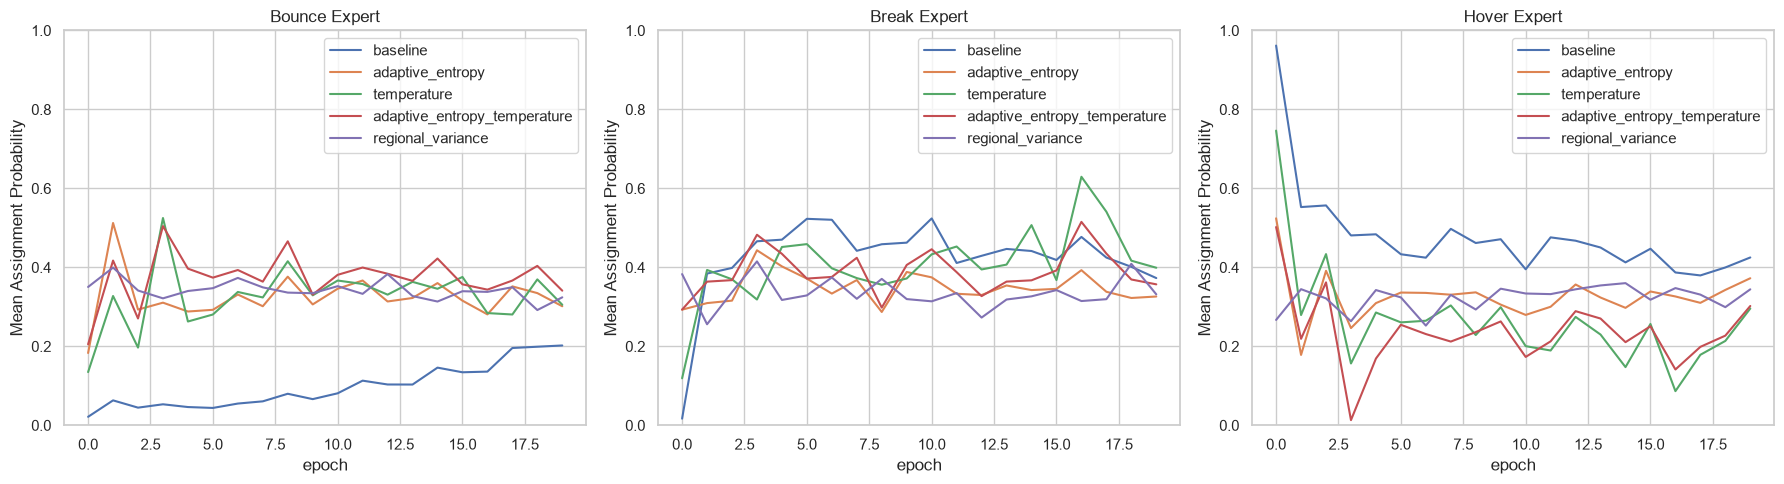

In [11]:
compare.plot_utilization(runs)

**Expert Utilization Analysis:**  
The charts above show the mean assignment probability of each expert over the training epochs. 
*   In the **baseline**, you will often see one expert "hog" all the routing (its probability climbs near $1.0$), while the others fall flat near $0.0$. 
*   In **adaptive_entropy**, you will see the experts tightly grouped around $0.33$ because the scaling factor violently penalizes any expert that tries to monopolize the data.
*   In **regional_variance**, the utilization is allowed to fluctuate dynamically as the model learns which regions belong to which expert.

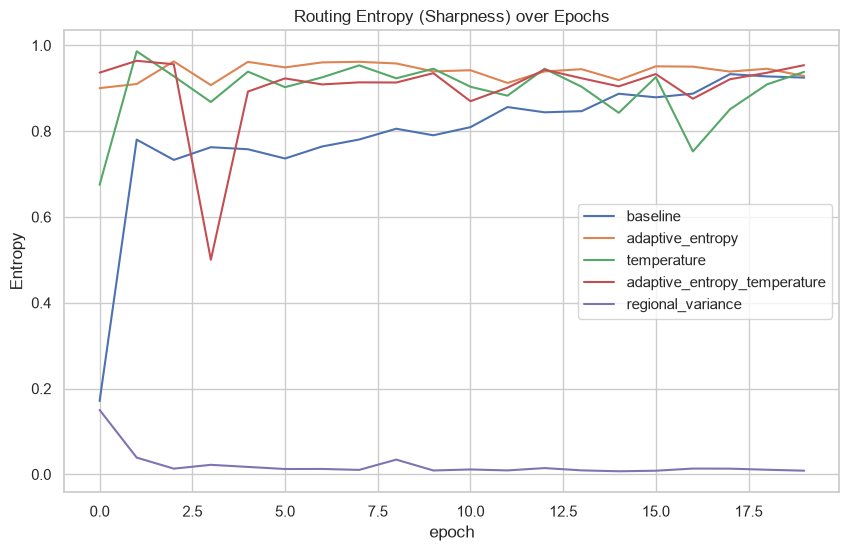

In [12]:
compare.plot_distance(runs)

**Entropy (Sharpness) Analysis:**  
This chart tracks the entropy of the routing decisions over time. A high entropy means the model is "indecisive" (e.g., $[0.33, 0.33, 0.33]$). A low entropy means the model is making sharp, confident routes ($[1.0, 0.0, 0.0]$). Notice how the variants using **Temperature Annealing** show a steep drop in entropy exactly as the temperature decays from $5.0 \to 0.5$, proving that the annealing schedule successfully solidifies hard routing.

## Generate Synthetic Samples
Generate MC samples for each variant so they can be loaded by `Statistical_comparison.ipynb`.

In [ ]:
from experiments.neural_SDE.generate_samples import main_mc_multi
import json
INSTANCE = "20261004_185041" # Run the benchmark and then choose the instance you want to use to generate sample
root_dir = Path(f"../../workspace/neural_SDE/gating_diagnostics_benchmark/{INSTANCE}").resolve()

print("Generating samples for variants...")
for name in BENCHMARK_VARIANTS.keys():
    print(f"\n=== Generating MC samples for {name} ===")
    variant_dir = root_dir / name
    manifest_path = variant_dir / "manifest.json"
    if not manifest_path.exists():
        print(f"No manifest found for {name}, skipping.")
        continue
    with open(manifest_path, "r") as f:
        manifest = json.load(f)
    checkpoint_path = manifest.get("checkpoint")
    if not checkpoint_path:
        print(f"No checkpoint found for {name}, skipping.")
        continue
    
    output_plot = Path(f"../../Data/Synthetic/{name}_synthetic_rollout_MC.png").resolve()
    output_plot.parent.mkdir(parents=True, exist_ok=True)
    
    # Check if samples already exist to avoid re-running
    if output_plot.with_name(f"{output_plot.stem}_valid_samples.npz").exists():
        print(f"Samples already exist for {name}, skipping.")
        continue
        
    main_mc_multi(
        trainer_cfg=cfg,
        checkpoint_path=checkpoint_path,
        batch_size=1000,
        mc_paths=20,
        n_steps=100,
        output_plot=output_plot,
        num_iids=max(2, int(cfg["dset_cfg"].get("num_iids", 50))),
        issue_id=None,
        test_date=None,
        seed_override=1
    )


Seed set to 1


Generating samples for variants...

=== Generating MC samples for baseline ===
Selected 100 issue IDs for dataset: ['01054901', '18403501', '00543901', '02111801', '00921601', '16054101', '12239401', '14570101', '06140601', '01707301', '00758501', '15686101', '00302401', '06296502', '10918301', '00118601', '12029701', '02260301', '01907101', '18773901', '00812301', '02819401', '00313801', '00257401', '00280701', '17676601', '00170601', '06151301', '01769901', '06658601', '00302801', '17090401', '01838301', '11336201', '16054901', '17906001', '01944201', '03082201', '01931801', '01804301', '13760901', '02504701', '00253601', '06564301', '17967101', '00799101', '01443301C', '02557201', '00946501', '02951701', '16212701', '16362601C', '01489101', '02641101', '02467801', '18716401', '16099101', '16287001C', '06340501', '18754901', '00333601', '15027801', '02021401', '06449201C', '06555601', '01366401', '03442901', '17808101', '03669101', '00694601', '11452401', '16369701C', '00846301', '01

NeuralSDEDataset: creating samples: 100%|██████████| 100/100 [00:00<00:00, 610.41it/s]
5 issue IDs were excluded - insufficient data.


Length of excluded Issue IDs: 5
Price windows shape: (101824, 252), Next prices shape: (101824, 1), Features shape: (101824, 7)
MC mode: issue_ids=50, initial_conditions=50, mc_paths_per_condition=20, total_paths=1000, n_steps=100, master_seed=1
Filtering security_data for IssueId=01707301, test_date=2016-12-05 00:00:00, row_window=[485:586), test_idx=485
Filtering security_data for IssueId=18537501, test_date=2016-08-09 00:00:00, row_window=[404:505), test_idx=404
Filtering security_data for IssueId=06140601, test_date=2017-01-30 00:00:00, row_window=[523:624), test_idx=523
Filtering security_data for IssueId=17808101, test_date=2019-02-19 00:00:00, row_window=[1039:1140), test_idx=1039
Filtering security_data for IssueId=19096302, test_date=2016-12-09 00:00:00, row_window=[490:591), test_idx=490
Filtering security_data for IssueId=16099101, test_date=2018-05-14 00:00:00, row_window=[847:948), test_idx=847
Filtering security_data for IssueId=00812301, test_date=2017-11-09 00:00:00, ro

Seed set to 1


...

Length of excluded Issue IDs: 5
Price windows shape: (101824, 252), Next prices shape: (101824, 1), Features shape: (101824, 7)
MC mode: issue_ids=50, initial_conditions=50, mc_paths_per_condition=20, total_paths=1000, n_steps=100, master_seed=1
Filtering security_data for IssueId=01707301, test_date=2016-12-05 00:00:00, row_window=[485:586), test_idx=485
Filtering security_data for IssueId=18537501, test_date=2016-08-09 00:00:00, row_window=[404:505), test_idx=404
Filtering security_data for IssueId=06140601, test_date=2017-01-30 00:00:00, row_window=[523:624), test_idx=523
Filtering security_data for IssueId=17808101, test_date=2019-02-19 00:00:00, row_window=[1039:1140), test_idx=1039
Filtering security_data for IssueId=19096302, test_date=2016-12-09 00:00:00, row_window=[490:591), test_idx=490
Filtering security_data for IssueId=16099101, test_date=2018-05-14 00:00:00, row_window=[847:948), test_idx=847
Filtering security_data for IssueId=00812301, test_date=2017-11-09 00:00:00, ro

Seed set to 1


Saved MC paths CSV to: /Users/daniel/Dev/GitHub/Repositories/fibonacci_neural_sde/Data/Synthetic/adaptive_entropy_temperature_synthetic_rollout_MC_paths.csv
Saved MC artifacts NPZ to: /Users/daniel/Dev/GitHub/Repositories/fibonacci_neural_sde/Data/Synthetic/adaptive_entropy_temperature_synthetic_rollout_MC_valid_samples.npz
Saved 50 MC ensemble plots under: /Users/daniel/Dev/GitHub/Repositories/fibonacci_neural_sde/Data/Synthetic
Sanity-valid MC paths: 944/1000

=== Generating MC samples for regional_variance ===
Selected 100 issue IDs for dataset: ['01054901', '18403501', '00543901', '02111801', '00921601', '16054101', '12239401', '14570101', '06140601', '01707301', '00758501', '15686101', '00302401', '06296502', '10918301', '00118601', '12029701', '02260301', '01907101', '18773901', '00812301', '02819401', '00313801', '00257401', '00280701', '17676601', '00170601', '06151301', '01769901', '06658601', '00302801', '17090401', '01838301', '11336201', '16054901', '17906001', '01944201', 

NeuralSDEDataset: creating samples: 100%|██████████| 100/100 [00:00<00:00, 487.46it/s]
5 issue IDs were excluded - insufficient data.


Length of excluded Issue IDs: 5
Price windows shape: (101824, 252), Next prices shape: (101824, 1), Features shape: (101824, 7)
MC mode: issue_ids=50, initial_conditions=50, mc_paths_per_condition=20, total_paths=1000, n_steps=100, master_seed=1
Filtering security_data for IssueId=01707301, test_date=2016-12-05 00:00:00, row_window=[485:586), test_idx=485
Filtering security_data for IssueId=18537501, test_date=2016-08-09 00:00:00, row_window=[404:505), test_idx=404
Filtering security_data for IssueId=06140601, test_date=2017-01-30 00:00:00, row_window=[523:624), test_idx=523
Filtering security_data for IssueId=17808101, test_date=2019-02-19 00:00:00, row_window=[1039:1140), test_idx=1039
Filtering security_data for IssueId=19096302, test_date=2016-12-09 00:00:00, row_window=[490:591), test_idx=490
Filtering security_data for IssueId=16099101, test_date=2018-05-14 00:00:00, row_window=[847:948), test_idx=847
Filtering security_data for IssueId=00812301, test_date=2017-11-09 00:00:00, ro